## <span style="color:#db7d60">Purpose</span>

The goal of this notebook is to showcase all the abilities of analysis_v2 and how to use them so users can easily analyze and optimize models.

In [13]:
%load_ext autoreload
%autoreload 2

import sys
import time
import json
import pickle
from collections import Counter, defaultdict
from types import SimpleNamespace
from itertools import islice
from pathlib import Path
# Math
import math
import numpy as np
import pandas as pd
from numba import njit, float64, types
from numba.experimental import jitclass
from numba.typed import Dict
from scipy.signal import savgol_filter
from numerize import numerize
# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from particle import Particle
import vector
import jetnet
import jetnet.evaluation

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))

# particleGPT
import pUtil
import data_manager
from analysis_common import *
import analysis_v2 as analv2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Set basic themeing and display options for optimal display of information

In [14]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Set use_text=True if a latex installation is avaliable.
analv2.plotting_v2.set_publication_style(base_fontsize=10, dpi=100, save_dpi=600, use_tex=False)

<Figure size 640x480 with 0 Axes>

### Run plots

#### Plot both training and validation runs

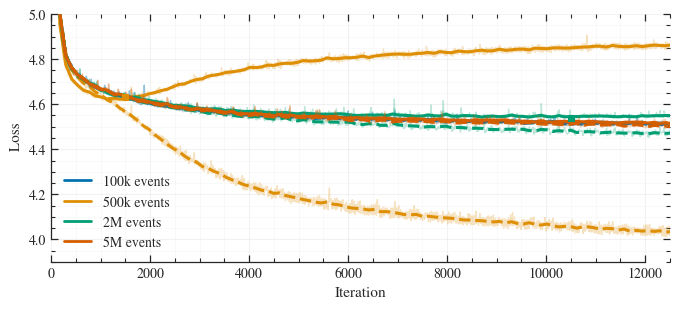

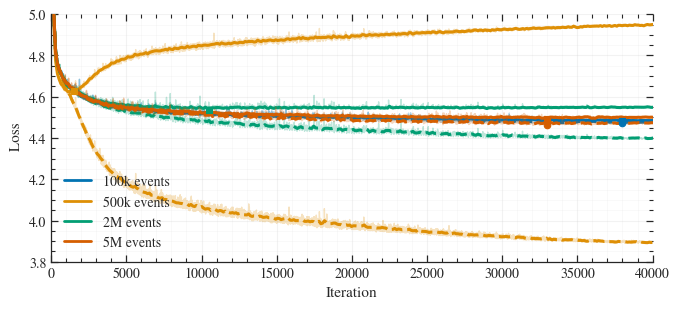

(<Figure size 690x320 with 1 Axes>, <Axes: xlabel='Iteration', ylabel=' Loss'>)

In [15]:
# Titles is the labels used in the legend
titles = ['100k events', '500k events', '2M events', '5M events']
models = ['model_10M_9_exp9_vdi_2', 'model_exp10_500k_lr1', 'model_exp10_2M_lr1', 'model_exp10_5M_lr1']
# This API is self-explanatory
analv2.plotting_v2.plot_training_run(models, model_legend_title=titles, show_train_loss=True, show_val_loss=True, show_best_marker=True, use_log=False, y_lim=(3.9, 5), x_lim=(0, 12500))
analv2.plotting_v2.plot_training_run(models, model_legend_title=titles, show_train_loss=True, show_val_loss=True, show_best_marker=True, use_log=False, y_lim=(3.8, 5), x_lim=(0, 40000))

#### Training run plots

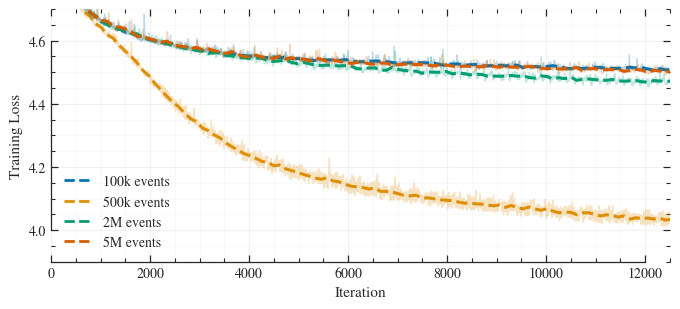

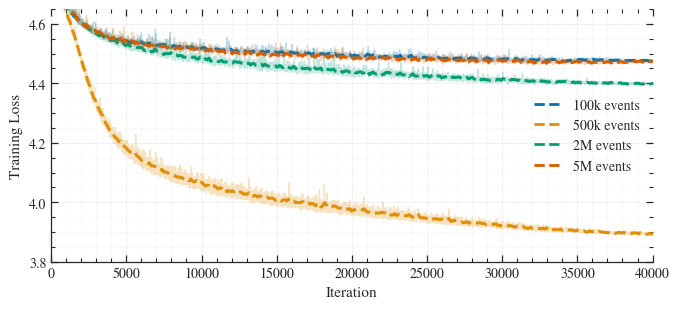

(<Figure size 690x320 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Training Loss'>)

In [16]:
# Titles is the labels used in the legend
titles = ['100k events', '500k events', '2M events', '5M events']
models = ['model_10M_9_exp9_vdi_2', 'model_exp10_500k_lr1', 'model_exp10_2M_lr1', 'model_exp10_5M_lr1']
# This API is self-explanatory
analv2.plotting_v2.plot_training_run(models, model_legend_title=titles, show_train_loss=True, use_log=False, y_lim=(3.9, 4.7), x_lim=(0, 12500))
analv2.plotting_v2.plot_training_run(models, model_legend_title=titles, show_train_loss=True, use_log=False, y_lim=(3.8, 4.65), x_lim=(0, 40000))

#### Validation run plots

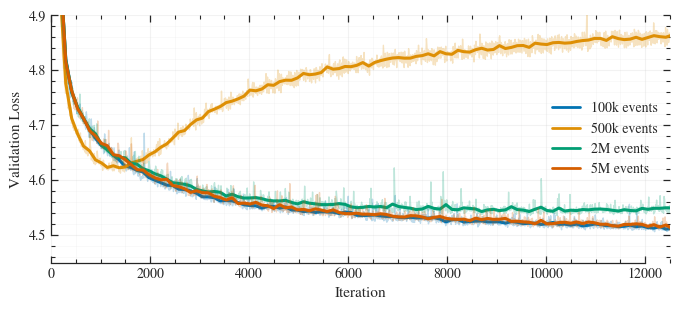

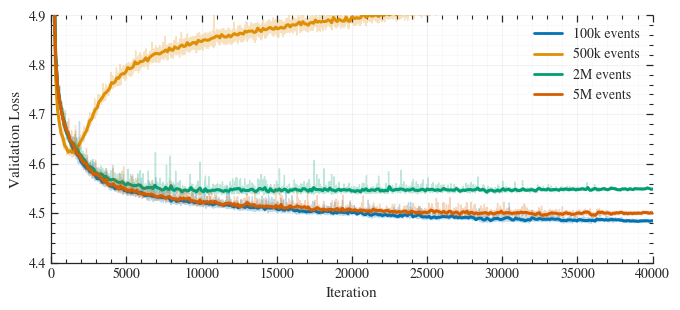

(<Figure size 690x320 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [17]:
# Titles is the labels used in the legend
titles = ['100k events', '500k events', '2M events', '5M events']
models = ['model_10M_9_exp9_vdi_2', 'model_exp10_500k_lr1', 'model_exp10_2M_lr1', 'model_exp10_5M_lr1']
# This API is self-explanatory
analv2.plotting_v2.plot_training_run(models, model_legend_title=titles, show_val_loss=True, use_log=False, y_lim=(4.45, 4.9), x_lim=(0, 12500))
analv2.plotting_v2.plot_training_run(models, model_legend_title=titles, show_val_loss=True, use_log=False, y_lim=(4.4, 4.9), x_lim=(0, 40000))

#### Same as above, but now with the learning rate schedule.

Only validation run in plotted for demonstration.

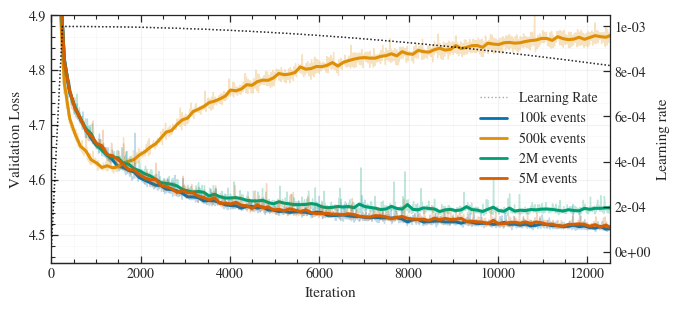

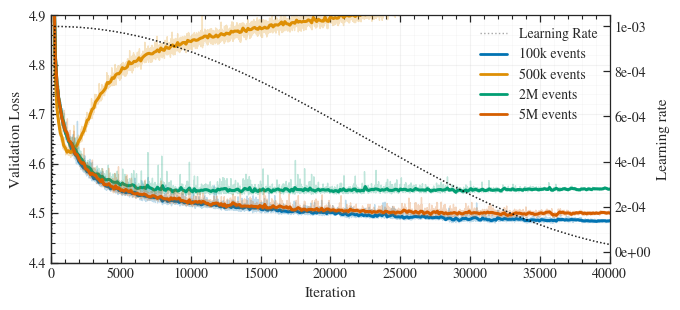

(<Figure size 690x320 with 2 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [18]:
# Titles is the labels used in the legend
titles = ['100k events', '500k events', '2M events', '5M events']
models = ['model_10M_9_exp9_vdi_2', 'model_exp10_500k_lr1', 'model_exp10_2M_lr1', 'model_exp10_5M_lr1']
# This API is self-explanatory
analv2.plotting_v2.plot_training_run(models, model_legend_title=titles, show_lr_schedule=True, show_val_loss=True, use_log=False, y_lim=(4.45, 4.9), x_lim=(0, 12500))
analv2.plotting_v2.plot_training_run(models, model_legend_title=titles, show_lr_schedule=True, show_val_loss=True, use_log=False, y_lim=(4.4, 4.9), x_lim=(0, 40000))

### Distribution plots

#### Load datasets using data_manager

In [19]:
models_to_compare = ['model_10M_9_exp9_vdimlr_1', 'model_10M_12_inclrrestarts_3']

real_verbose_data = data_manager.load_verbose_dataset(
    pUtil.get_model_preparation_dir(models_to_compare[0]) / "real_verbose_test_particles.csv",
    pad_token=np.nan
)

gen_verbose_data_dict = {}
for mn in models_to_compare:
    sampled_verbose_data = data_manager.load_verbose_dataset(
        pUtil.get_latest_sampling_dir(mn) / "untokenized_samples_verbose.csv",
        pad_token=np.nan
    )
    gen_verbose_data_dict[mn] = sampled_verbose_data

#### Plot distribution features for all particles

all outgoing particles
pt


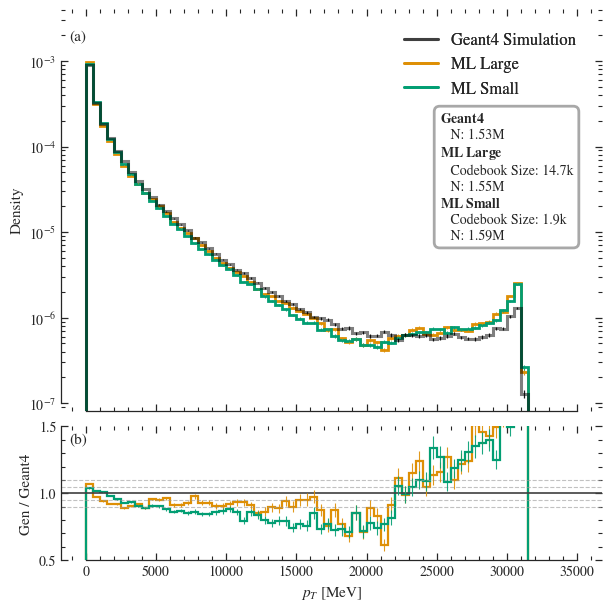

eta


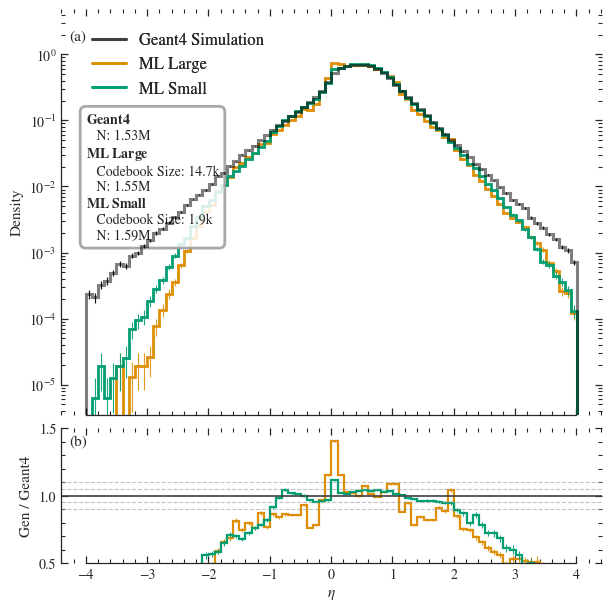

phi


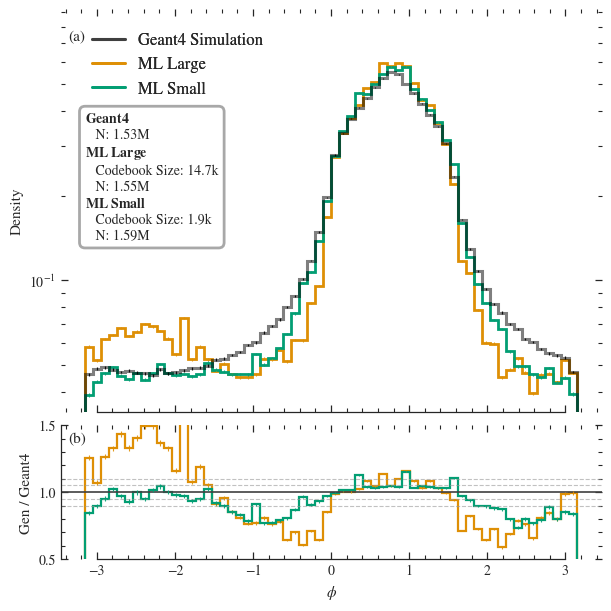

In [20]:
all_columns = ["pt", "eta", "phi"]
models_legend_titles = ['Geant4 Simulation', 'ML Large', 'ML Small']

print(f"all outgoing particles")
for column_name in all_columns:
    print(f"{column_name}")
    
    # analysis_v2.dataset provides methods to easily extract a single column for analysis
    gen_data_dict = {}
    pdata_real = analv2.dataset.extract_single_column_for_analysis(real_verbose_data, column_name, return_only_leading=False)
    for mn in models_to_compare:
        pdata_gen = analv2.dataset.extract_single_column_for_analysis(gen_verbose_data_dict[mn], column_name, return_only_leading=False)
        gen_data_dict[mn] = pdata_gen
    
    # Annotations can be made in-figure using either text or a table.
    spec_text = (
        r"$ \bf{Geant4} $" "\n"
        f"   N: {numerize.numerize(len(pdata_real))}\n"
        r"$ \bf{ML \ Large} $" "\n"
         "   Codebook Size: 14.7k\n"
        f"   N: {numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))}\n"
        r"$ \bf{ML \ Small} $" "\n"
         "   Codebook Size: 1.9k\n"
        f"   N: {numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))}"
    )
    
    # Table by default has three rows: [Generator Name, Codebook Size, N data plotted]
    spec_table_rows = [
        ("Geant4", "-", numerize.numerize(len(pdata_real))),
        ("ML Large", "14.7k", numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))),
        ("ML Small", "1.9k", numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))),
    ]
    
    # analysis_v2.plotting_v2 will handle legend and annotation placement.
    analv2.plotting_v2.plot_dist_and_ratio_cont(
        column_name=column_name,
        edges=None,
        ref_vals=pdata_real,
        comp_vals_dict=gen_data_dict,
        model_legend_titles=models_legend_titles,
        density=True,
        use_log=True,
        out_file=None,
        title=None,
        spec_text=spec_text,
        # spec_table_rows=spec_table_rows
    )

#### Plot distributions for leading particles

leading particles
pt


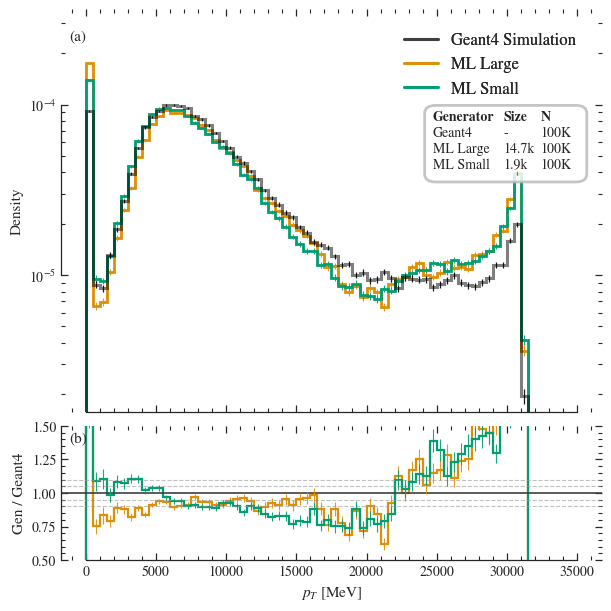

eta


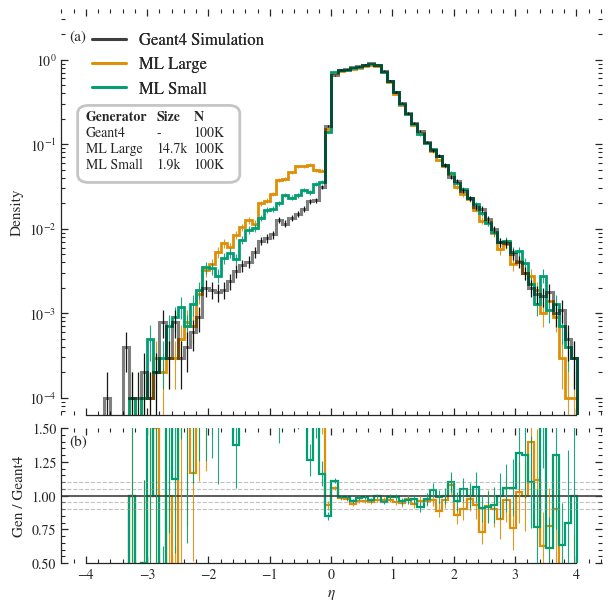

phi


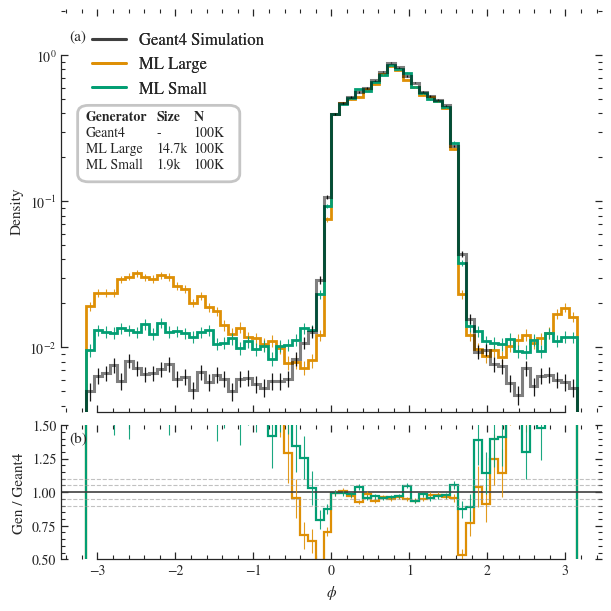

In [21]:
# The same can be done for leading particles, but this time return_only_leading=True for analv2.dataset.process_data_for_analysis
print(f"leading particles")
for column_name in all_columns:
    print(f"{column_name}")
    
    # analysis_v2.dataset provides methods to easily extract a single column from only leading particles for analysis
    gen_data_dict = {}
    pdata_real = analv2.dataset.extract_single_column_for_analysis(real_verbose_data, column_name, return_only_leading=True)
    for mn in models_to_compare:
        pdata_gen = analv2.dataset.extract_single_column_for_analysis(gen_verbose_data_dict[mn], column_name, return_only_leading=True)
        gen_data_dict[mn] = pdata_gen
    
    spec_text = (
        r"$ \bf{Geant4} $" "\n"
        f"   N: {numerize.numerize(len(pdata_real))}\n"
        r"$ \bf{ML \ Large} $" "\n"
         "   Codebook Size: 14.7k\n"
        f"   N: {numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))}\n"
        r"$ \bf{ML \ Small} $" "\n"
         "   Codebook Size: 1.9k\n"
        f"   N: {numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))}"
    )
    
    spec_table_rows = [
        ("Geant4", "-", numerize.numerize(len(pdata_real))),
        ("ML Large", "14.7k", numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))),
        ("ML Small", "1.9k", numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))),
    ]
    
    analv2.plotting_v2.plot_dist_and_ratio_cont(
        column_name=column_name,
        edges=None,
        ref_vals=pdata_real,
        comp_vals_dict=gen_data_dict,
        model_legend_titles=models_legend_titles,
        density=True,
        use_log=True,
        out_file=None,
        title=None,
        # spec_text=spec_text,
        spec_table_rows=spec_table_rows
    )

#### Plotting PDGIDs for all particles

All outgoing PDGIDs


(<Figure size 600x600 with 2 Axes>,
 (<Axes: ylabel='Counts ($\\times 10^{5}$)'>,
  <Axes: xlabel='PDGID', ylabel='Gen / Geant4'>))

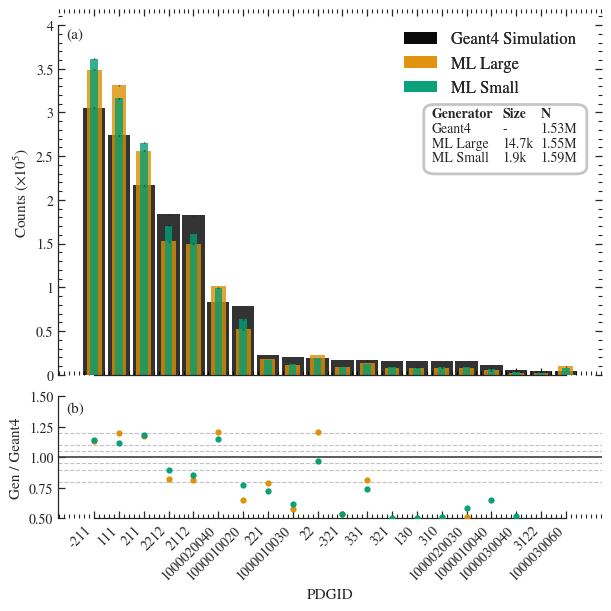

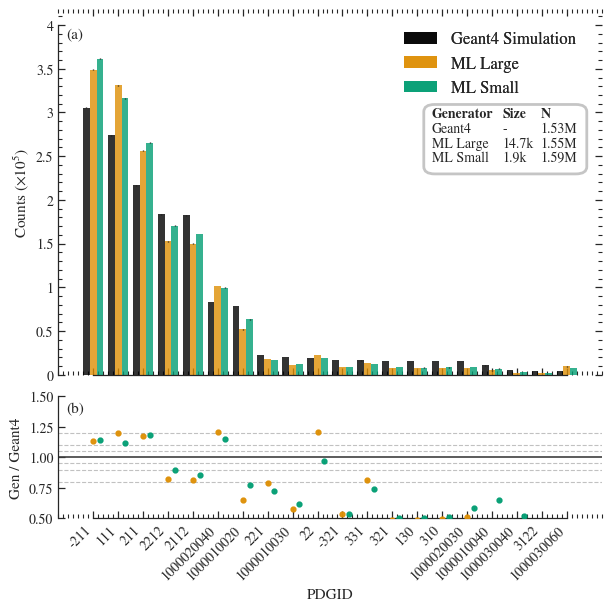

In [22]:
print(f"All outgoing PDGIDs")

relevant_column_pos = analv2.plotting_v2.verbose_columns.index("pdgid")

# analysis_v2.dataset provides methods to easily extract a single column from only leading particles for analysis
gen_data_dict = {}
pdata_real = analv2.dataset.extract_single_column_for_analysis(real_verbose_data, "pdgid", return_only_leading=False)
for mn in models_to_compare:
    pdata_gen = analv2.dataset.extract_single_column_for_analysis(gen_verbose_data_dict[mn], "pdgid", return_only_leading=False)
    gen_data_dict[mn] = pdata_gen

spec_text = (
    r"$ \bf{Geant4} $" "\n"
    f"   N: {numerize.numerize(len(pdata_real))}\n"
    r"$ \bf{ML \ Large} $" "\n"
     "   Codebook Size: 14.7k\n"
    f"   N: {numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))}\n"
    r"$ \bf{ML \ Small} $" "\n"
     "   Codebook Size: 1.9k\n"
    f"   N: {numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))}"
)

spec_table_rows = [
    ("Geant4", "-", numerize.numerize(len(pdata_real))),
    ("ML Large", "14.7k", numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))),
    ("ML Small", "1.9k", numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))),
]

analv2.plotting_v2.plot_dist_and_ratio_discrete_overlaid(
    column_name='pdgid',
    ref_vals=pdata_real,
    comp_vals_dict=gen_data_dict,
    model_legend_titles=models_legend_titles,
    density=False,
    use_log=False,
    out_file=None,
    title=None,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
    top_k=20,
    sort_descending=True
)

analv2.plotting_v2.plot_dist_and_ratio_discrete_grouped(
    column_name='pdgid',
    ref_vals=pdata_real,
    comp_vals_dict=gen_data_dict,
    model_legend_titles=models_legend_titles,
    density=False,
    use_log=False,
    out_file=None,
    title=None,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
    top_k=20,
    sort_descending=True
)

#### Plotting frequency of a certain number of secondaries per event

(<Figure size 600x600 with 2 Axes>,
 (<Axes: ylabel='Counts ($\\times 10^{3}$)'>,
  <Axes: xlabel='Outgoing Particles Count', ylabel='Gen / Geant4'>))

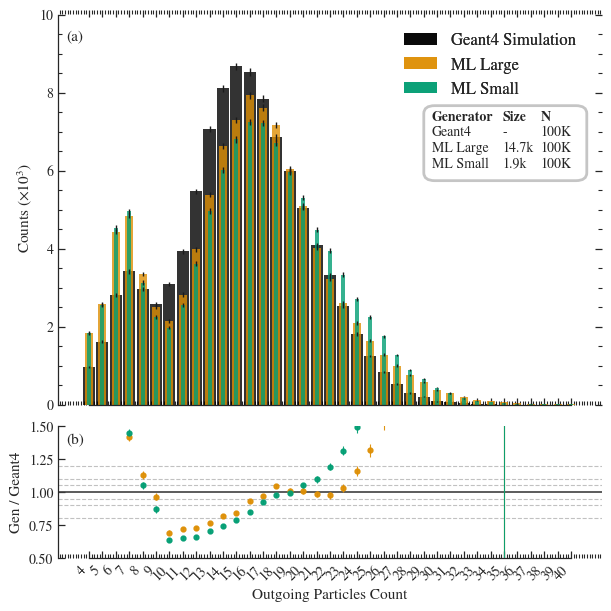

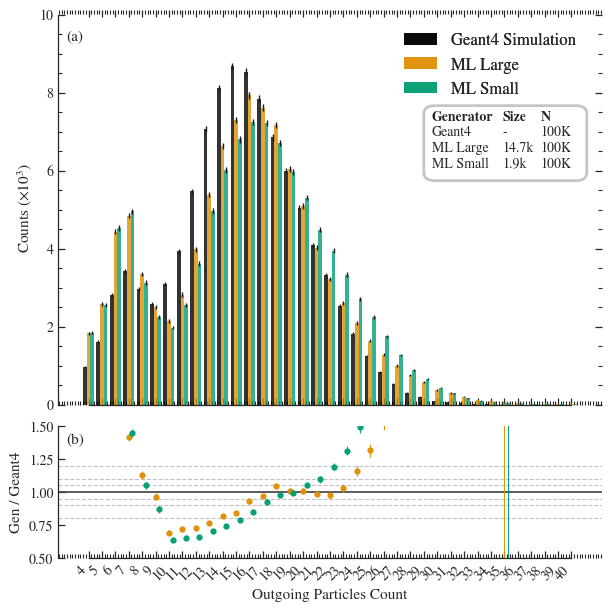

In [23]:
gen_data_dict = {}
pdata_real = analv2.dataset.extract_single_column_for_analysis(real_verbose_data, "num_particles")
for mn in models_to_compare:
    pdata_gen = analv2.dataset.extract_single_column_for_analysis(gen_verbose_data_dict[mn], "num_particles")
    gen_data_dict[mn] = pdata_gen

spec_text = (
    r"$ \bf{Geant4} $" "\n"
    f"   N: {numerize.numerize(len(pdata_real))}\n"
    r"$ \bf{ML \ Large} $" "\n"
     "   Codebook Size: 14.7k\n"
    f"   N: {numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))}\n"
    r"$ \bf{ML \ Small} $" "\n"
     "   Codebook Size: 1.9k\n"
    f"   N: {numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))}"
)

spec_table_rows = [
    ("Geant4", "-", numerize.numerize(len(pdata_real))),
    ("ML Large", "14.7k", numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))),
    ("ML Small", "1.9k", numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))),
]

analv2.plotting_v2.plot_dist_and_ratio_discrete_overlaid(
    column_name='num_particles',
    ref_vals=pdata_real,
    comp_vals_dict=gen_data_dict,
    model_legend_titles=models_legend_titles,
    density=False,
    use_log=False,
    out_file=None,
    title=None,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
)

analv2.plotting_v2.plot_dist_and_ratio_discrete_grouped(
    column_name='num_particles',
    ref_vals=pdata_real,
    comp_vals_dict=gen_data_dict,
    model_legend_titles=models_legend_titles,
    density=False,
    use_log=False,
    out_file=None,
    title=None,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
)


### Energy conservation

Finally, there is an energy conservation plot.

In [24]:
# This calculation takes a while, so we do it here
real_ein, real_eout = analv2.dataset.extract_ein_eout_for_analysis(models_to_compare[0], real_verbose_data)
gen_data_dict = {}
for mn in models_to_compare:
    gen_ein, gen_eout = analv2.dataset.extract_ein_eout_for_analysis(mn, gen_verbose_data_dict[mn])
    gen_data_dict[mn] = gen_ein, gen_eout

One way to do this is to compare input and output energies for the same model.

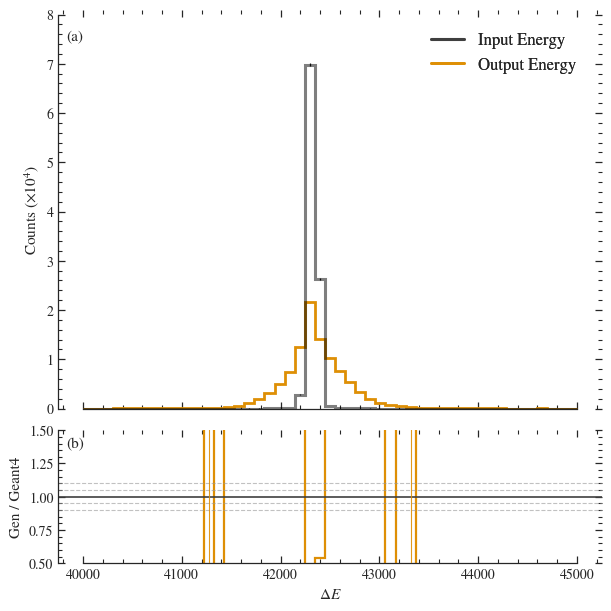

(<Figure size 600x600 with 2 Axes>,
 (<Axes: ylabel='Counts ($\\times 10^{4}$)'>,
  <Axes: xlabel='$ \\Delta E $', ylabel='Gen / Geant4'>))

In [25]:
models_to_compare = ['model_10M_9_exp9_vdimlr_1']
models_legend_titles = ['Input Energy', 'Output Energy']

list_item_idx = 0
comparision_model_name, (ein, eout) = next(islice(gen_data_dict.items(), list_item_idx, None))

edges = np.linspace(40E3, 45E3, 50)
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name='energy_conservation',
    ref_vals=ein,
    comp_vals_dict={comparision_model_name: eout},
    model_legend_titles=models_legend_titles,
    edges=edges,
    density=False,
    use_log=False,
    out_file=None,
    title=None,
)

Another way, is to compare outputs across models separately, using a reference input.

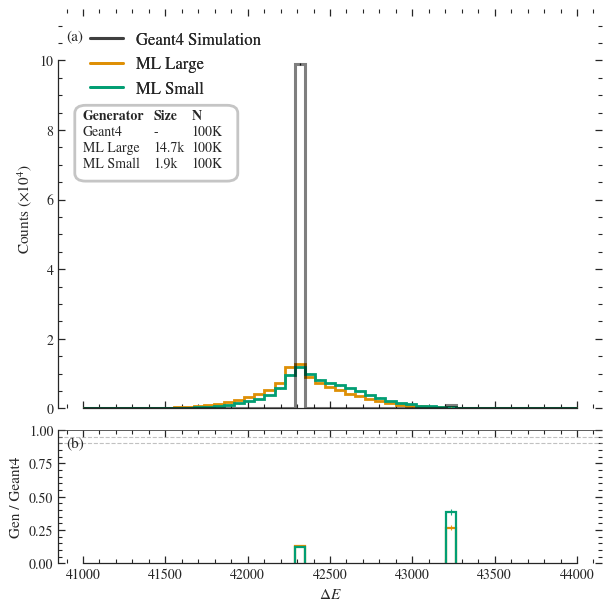

(<Figure size 600x600 with 2 Axes>,
 (<Axes: ylabel='Counts ($\\times 10^{4}$)'>,
  <Axes: xlabel='$ \\Delta E $', ylabel='Gen / Geant4'>))

In [26]:
models_to_compare = ['model_10M_9_exp9_vdimlr_1', 'model_10M_12_inclrrestarts_3']
models_legend_titles = ['Geant4 Simulation', 'ML Large', 'ML Small']

gen_ein_dict = {mn: tup[0] for mn, tup in gen_data_dict.items()}
gen_eout_dict = {mn: tup[1] for mn, tup in gen_data_dict.items()}
gen_names = list(gen_data_dict.keys())
all_names = [models_to_compare[0]] + gen_names

spec_table_rows = [
    ("Geant4", "-", numerize.numerize(len(pdata_real))),
    ("ML Large", "14.7k", numerize.numerize(len(gen_eout_dict['model_10M_9_exp9_vdimlr_1']))),
    ("ML Small", "1.9k", numerize.numerize(len(gen_eout_dict['model_10M_12_inclrrestarts_3']))),
]

edges = np.linspace(41E3, 44E3, 50)
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name='energy_conservation',
    ref_vals=real_eout,
    comp_vals_dict=gen_eout_dict,
    model_legend_titles=models_legend_titles,
    edges=edges,
    density=False,
    use_log=False,
    out_file=None,
    title=None,
    ratio_ylim=(0, 1),
    # spec_text="Outgoing particles only",
    spec_table_rows=spec_table_rows,
)